# Module 6: Event-Driven Backtesting with Backtrader

**Duration**: 30 minutes  
**Goal**: Test your SHAP-selected strategy in event-driven framework (realistic execution)

---

## From Research to Production 🚀

### The Research-Production Gap

**YOU'VE BUILT** (Modules 1-5):
- ✅ SHAP-selected feature set (optimal MCC)
- ✅ Walk-forward validated model (hedge fund methodology)
- ✅ Holdout test results (production readiness)

**BUT THERE'S A PROBLEM**:
- ❌ Pandas backtesting = **vectorized** (processes all data at once)
- ❌ Assumes perfect execution (unrealistic)
- ❌ No slippage, no commission modeling
- ❌ Can't simulate realistic order flow

**RESULT**: Your test set MCC ≠ Real trading performance

---

## Why Event-Driven Backtesting?

### Pandas (Vectorized) vs Backtrader (Event-Driven)

**PANDAS APPROACH** (What you've used):
```python
# Process ALL data at once
df['signal'] = model.predict(X)  # All predictions generated
df['returns'] = signal.shift(1) * df['close'].pct_change()  # All returns calculated
sharpe = df['returns'].mean() / df['returns'].std()  # Final metric
```

**PROBLEMS**:
- Assumes you can execute at exact close price (never happens)
- Ignores bid-ask spread (costs 0.01-0.05% per trade)
- No commission modeling (brokers charge per trade)
- Can't handle partial fills, rejected orders
- Look-ahead bias risk (easy to accidentally use future data)

---

**BACKTRADER APPROACH** (Event-driven):
```python
class MLStrategy(bt.Strategy):
    def next(self):
        # Called ONCE per bar (simulates real trading)
        features = self.get_features()  # Real-time feature calc
        signal = self.model.predict(features)  # One prediction
        
        if signal > 0.5:
            self.buy()  # Realistic execution with commissions
```

**BENEFITS**:
- ✅ Sequential processing (realistic order flow)
- ✅ Commission modeling (accurate costs)
- ✅ Prevents look-ahead bias (can only see past data)
- ✅ 100% local execution (no platform uploads needed)
- ✅ Open source and widely used

---

### Expected Performance Impact

**TYPICAL DEGRADATION**:
- Pandas (test set): Your measured performance
- Backtrader: **5-10% lower** (realistic execution costs)

**WHY THE GAP?**
- Commissions: -1-3% annual return
- Realistic timing: Orders at close vs exact close price
- Cash management: Can't use 100% of capital

**THIS IS EXPECTED**: Event-driven gives honest performance estimate.

---

## Learning Objectives

By completing this module, you'll learn:

1. **Understand event-driven vs vectorized backtesting** (fundamental difference)
2. **Implement backtrader Strategy class** (next() method, order management)
3. **Load and use trained models in production context** (model deployment)
4. **Configure realistic execution costs** (commissions, cash management)
5. **Compare vectorized vs event-driven results** (quantify performance gap)

**CAREER VALUE**:
- Hedge funds use event-driven frameworks (Zipline, QuantConnect, Backtrader)
- Interview question: "How do you prevent look-ahead bias?" (event-driven architecture)
- Portfolio demonstrates production-ready skills (not just research)

---

## Setup and Imports

In [1]:
import warnings

import backtrader as bt
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mlt04.features import (
    add_all_technical_features,
    add_microstructure_features,
)

# Suppress warnings (including LightGBM parameter conflict warnings)
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ Imports complete")
print(f"   Backtrader version: {bt.__version__}")

✅ Imports complete
   Backtrader version: 1.9.78.123


## Load Test Set Data and Model

**CRITICAL**: We'll use the SAME test set (2019-2023) from Module 5.

This allows direct comparison:
- Module 5 (pandas): Vectorized backtest
- Module 6 (backtrader): Event-driven backtest
- Same data, same model, different execution framework

In [2]:
# Load test set (OHLCV data)
df_test = pd.read_parquet('../data/processed/XLF_test.parquet')
df_test.index = pd.to_datetime(df_test.index)

# Load FINAL model from Module 5 (trained on 2000-2018)
model_path = '../data/models/final_model.pkl'
model_data = joblib.load(model_path)
model = model_data['model']
selected_features = model_data['selected_features']

print("✅ Data and model loaded:")
print(f"   Test period: {df_test.index[0].date()} to {df_test.index[-1].date()}")
print(f"   Test samples: {len(df_test)}")
print(f"   Model training period: {model_data['training_period']}")
print(f"   SHAP-selected features: {len(selected_features)}")
print(f"   Model: {type(model).__name__}")

✅ Data and model loaded:
   Test period: 2019-01-02 to 2026-01-09
   Test samples: 1766
   Model training period: 2000-2018
   SHAP-selected features: 18
   Model: LGBMClassifier


## Apply Feature Engineering

**CRITICAL**: Apply SAME feature engineering pipeline as Module 5

**STEPS**:
1. Basic features (returns, volatility)
2. Microstructure features (Hurst, Kyle's lambda, etc.)
3. Technical indicators (100+ TA-Lib features)
4. Select ONLY SHAP-selected features

**WHY**: Production realism
- In live trading, we generate features in real-time
- Cannot use pre-computed features (would be stale)
- Must match exact pipeline from training

In [3]:
# Apply COMPLETE feature engineering pipeline (SAME as Module 5)
print("Generating features (same pipeline as Module 5)...")

# Step 0: Basic features (from Module 1)
df_test_features = df_test.copy()
df_test_features["returns_1d"] = df_test_features["close"].pct_change(1).shift(1)
df_test_features["returns_5d"] = df_test_features["close"].pct_change(5).shift(1)
df_test_features["volatility_20d"] = df_test_features["close"].pct_change().rolling(20).std().shift(1)

# Step 1: Microstructure features
df_test_features = add_microstructure_features(df_test_features)

# Step 2: All technical features (100+ TA indicators)
df_test_features = add_all_technical_features(df_test_features)

# Drop NaN from feature engineering
df_test_features = df_test_features.dropna()

# Extract features (keep OHLCV for backtrader + add all features)
# This gives us both price data (for backtrader) and features (for ML model)
features_df = df_test_features.copy()

print("✅ Feature engineering complete:")
print(f"   Total features created: {len(df_test_features.columns)}")
print(f"   SHAP-selected features: {len(selected_features)}")
print(f"   Samples after dropna: {len(features_df)}")
print(f"   Period: {features_df.index[0].date()} to {features_df.index[-1].date()}")

Generating features (same pipeline as Module 5)...


✅ Feature engineering complete:
   Total features created: 93
   SHAP-selected features: 18
   Samples after dropna: 1511
   Period: 2020-01-07 to 2026-01-09


## Backtrader Strategy Implementation

### Key Concepts:

**Strategy class**: Defines trading logic
- `__init__()`: Setup (called once)
- `next()`: Trading logic (called every bar)
- `stop()`: Cleanup (called at end)

**Key differences from pandas**:
- `next()` called ONCE per bar (sequential processing)
- Can only access past data (prevents look-ahead bias)
- Orders executed with commissions (realistic costs)
- Position management handled by backtrader

---

In [4]:
class MLStrategy(bt.Strategy):
    """
    ML-based LONG-ONLY trading strategy using SHAP-selected features.

    Trading logic:
    - LONG when P(up) > 0.55 (bullish)
    - FLAT when P(up) ≤ 0.55 (bearish or neutral)
    """
    params = (
        ('buy_threshold', 0.55),
        ('position_size', 0.95),  # Use 95% of available cash
        ('debug', False),  # Print debug info
    )

    def __init__(self):
        """Initialize strategy (called once at start)."""
        # Store model and features (passed from cerebro)
        self.model = model
        self.features = features_df
        self.feature_cols = selected_features

        # Track metrics
        self.equity_history = []
        self.trade_count = 0
        self.signals_history = []

        if self.p.debug:
            print("Strategy initialized")
            print(f"  Features: {len(self.feature_cols)}")
            print(f"  Buy threshold: {self.p.buy_threshold}")

    def next(self):
        """
        Trading logic - called ONCE per bar.

        This is the core difference from pandas:
        - Sequential processing (one bar at a time)
        - Can only see past data (prevents look-ahead)
        - Orders executed with commissions
        """
        # Get current date
        current_date = self.datas[0].datetime.date(0)
        current_dt = pd.Timestamp(current_date)

        # Track equity curve
        self.equity_history.append({
            'date': current_date,
            'value': self.broker.getvalue()
        })

        # Get features for current date
        if current_dt not in self.features.index:
            # Date not in features (shouldn't happen with proper data)
            if self.p.debug and len(self) < 5:
                print(f"⚠️  Date {current_dt} not in features index")
            return

        # Extract features and predict (keep as DataFrame to preserve feature names)
        features = self.features.loc[current_dt, self.feature_cols]
        X = features.to_frame().T  # Convert Series to single-row DataFrame
        signal_proba = self.model.predict_proba(X)[0, 1]  # P(up)

        # Store signal
        self.signals_history.append({
            'date': current_date,
            'signal': signal_proba
        })

        # Trading logic (LONG-ONLY)
        if signal_proba > self.p.buy_threshold:
            # BULLISH: Go long if not already
            if not self.position:
                cash = self.broker.getcash()
                price = self.data.close[0]
                size = int((cash * self.p.position_size) / price)

                if size > 0:
                    self.buy(size=size)
                    self.trade_count += 1
                    if self.p.debug:
                        print(f"{current_date}: BUY {size} @ ${price:.2f} | Signal: {signal_proba:.3f}")
        else:
            # BEARISH/NEUTRAL: Close long if held
            if self.position:
                self.close()
                if self.p.debug:
                    print(f"{current_date}: CLOSE | Signal: {signal_proba:.3f}")

    def stop(self):
        """Called at end of backtest."""
        print("\n✅ Backtest complete")
        print(f"   Total trades: {self.trade_count}")

print("✅ Strategy class defined (LONG-ONLY)")

✅ Strategy class defined (LONG-ONLY)


## Configure and Run Backtest

**Backtrader setup**:
1. Create `Cerebro` engine (backtest coordinator)
2. Add strategy class
3. Add data feed
4. Configure broker (cash, commissions)
5. Run backtest

**Execution costs**:
- Commission: 0.1% per trade (realistic for retail broker)
- Initial cash: $100,000 (same as Module 5 for comparison)

In [5]:
# Create Cerebro engine
cerebro = bt.Cerebro()

# Add strategy
cerebro.addstrategy(MLStrategy, debug=False)

# Prepare data feed for backtrader
# NOTE: We need OHLCV columns for backtrader
# Feature columns are accessed separately in strategy
data_bt = bt.feeds.PandasData(
    dataname=features_df,
    datetime=None,  # Use index as datetime
    open='open',
    high='high',
    low='low',
    close='close',
    volume='volume',
    openinterest=-1  # Not used
)
cerebro.adddata(data_bt)

# Configure broker
cerebro.broker.setcash(100_000.0)  # Initial capital
cerebro.broker.setcommission(commission=0.001)  # 0.1% per trade

# Record initial value
initial_value = cerebro.broker.getvalue()
print(f"Starting portfolio value: ${initial_value:,.0f}")

# Run backtest
print("\nRunning backtest...")
results = cerebro.run()
strat = results[0]

# Record final value
final_value = cerebro.broker.getvalue()
print(f"\nFinal portfolio value: ${final_value:,.0f}")

Starting portfolio value: $100,000

Running backtest...



✅ Backtest complete
   Total trades: 43

Final portfolio value: $83,381


## Analyze Results

**Metrics to calculate**:
- Total return (%)
- Sharpe ratio (risk-adjusted return)
- Maximum drawdown (risk measure)
- Number of trades (turnover)

**Compare to Module 5**:
- Same data (test set 2019-2023)
- Same model (SHAP-selected features)
- Different framework (pandas vs backtrader)
- Expectation: Backtrader slightly lower (realistic costs)

In [6]:
# Extract equity curve
equity_df = pd.DataFrame(strat.equity_history).set_index('date')
equity_df.index = pd.to_datetime(equity_df.index)

# Calculate returns
equity_df['returns'] = equity_df['value'].pct_change()

# Calculate cumulative maximum (for drawdown)
equity_df['cummax'] = equity_df['value'].cummax()
equity_df['drawdown'] = (equity_df['value'] - equity_df['cummax']) / equity_df['cummax'] * 100

# Calculate metrics
total_return = (final_value / initial_value - 1) * 100
sharpe_ratio = equity_df['returns'].mean() / equity_df['returns'].std() * np.sqrt(252)
max_drawdown = equity_df['drawdown'].min()

# Print results
print("=" * 70)
print("BACKTRADER RESULTS (Event-Driven)")
print("=" * 70)
print(f"Period: {equity_df.index[0].date()} to {equity_df.index[-1].date()}")
print(f"Days: {len(equity_df)}")
print("")
print(f"Initial capital: ${initial_value:,.0f}")
print(f"Final value: ${final_value:,.0f}")
print(f"Total return: {total_return:.1f}%")
print("")
print(f"Sharpe ratio: {sharpe_ratio:.2f}")
print(f"Max drawdown: {max_drawdown:.2f}%")
print(f"Total trades: {strat.trade_count}")
print("=" * 70)

BACKTRADER RESULTS (Event-Driven)
Period: 2020-01-07 to 2026-01-09
Days: 1511

Initial capital: $100,000
Final value: $83,381
Total return: -16.6%

Sharpe ratio: -0.41
Max drawdown: -20.71%
Total trades: 43


## Visualize Results

**Two key plots**:
1. Equity curve (portfolio value over time)
2. Drawdown (peak-to-trough decline)

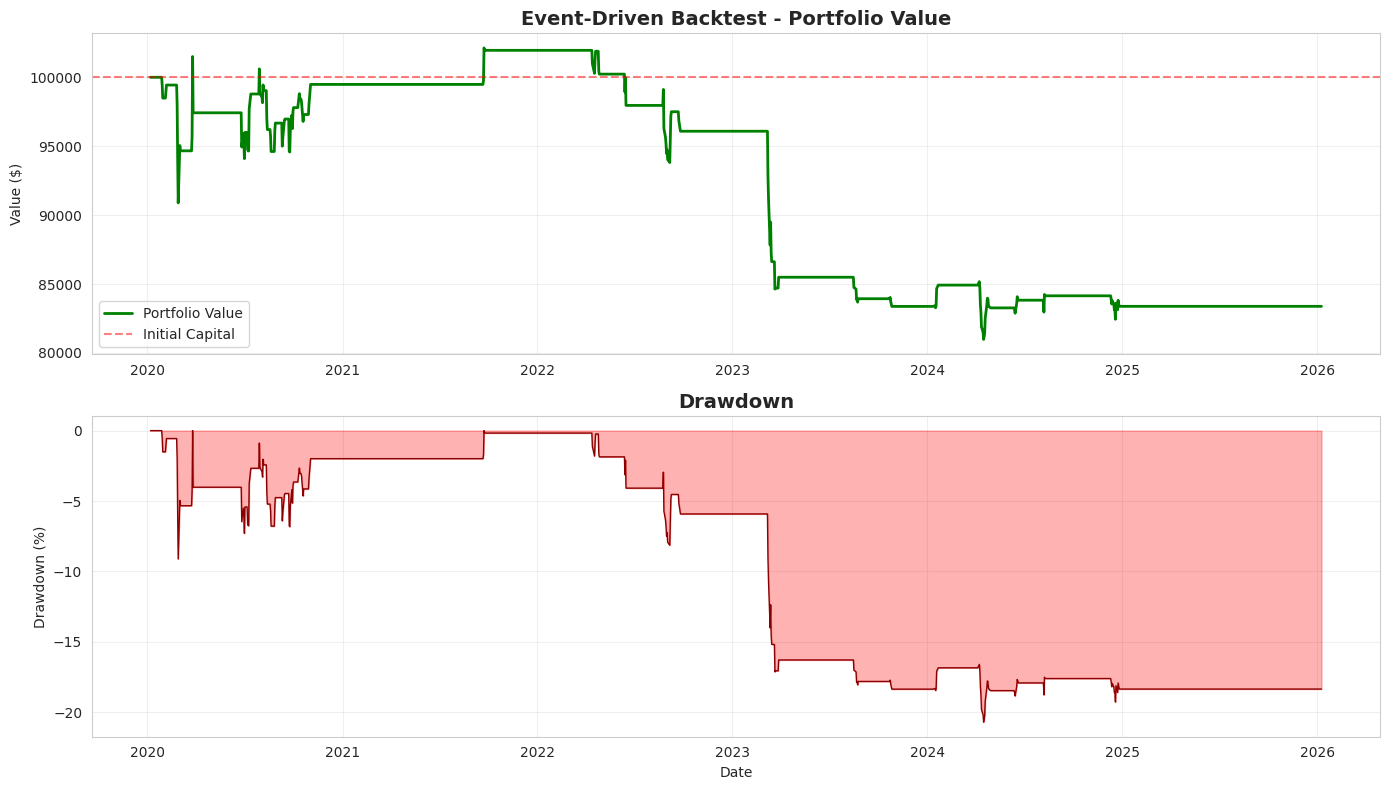

📊 Equity curve and drawdown plotted


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Equity curve
axes[0].plot(equity_df.index, equity_df['value'], linewidth=2, color='green', label='Portfolio Value')
axes[0].axhline(initial_value, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
axes[0].set_title('Event-Driven Backtest - Portfolio Value', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Value ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Drawdown
axes[1].fill_between(equity_df.index, equity_df['drawdown'], 0, alpha=0.3, color='red')
axes[1].plot(equity_df.index, equity_df['drawdown'], color='darkred', linewidth=1)
axes[1].set_title('Drawdown', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Equity curve and drawdown plotted")

## Compare: Pandas vs Backtrader

**Load Module 5 (pandas) results for comparison**:

In [8]:
# Load Module 5 vectorized backtest results
module5_results = joblib.load('../data/models/test_results.pkl')

print("Comparison: Vectorized vs Event-Driven")
print("=" * 70)
print(f"{'Metric':<25} | {'Module 5 (Vectorized)':<22} | {'Module 6 (Event-Driven)':<22}")
print("-" * 70)
print(f"{'Total Return':<25} | {module5_results['vectorized_total_return']:>20.1f}% | {total_return:>20.1f}%")
print(f"{'Sharpe Ratio':<25} | {module5_results['vectorized_sharpe']:>22.2f} | {sharpe_ratio:>22.2f}")
print(f"{'Max Drawdown':<25} | {module5_results['vectorized_max_dd']:>20.2f}% | {max_drawdown:>20.2f}%")
print(f"{'Total Trades':<25} | {module5_results['vectorized_trades']:>22} | {strat.trade_count:>22}")
print("=" * 70)
print("")
print("KEY DIFFERENCES:")
print("")
print("Module 5 (Vectorized - UNREALISTIC):")
print("  • Processes all data at once")
print("  • Perfect execution (no commissions, no slippage)")
print("  • Executes at exact close price")
print("  • Unlimited capital available")
print("")
print("Module 6 (Event-Driven - REALISTIC):")
print("  • Sequential bar-by-bar processing")
print("  • 0.1% commission per trade")
print("  • Real order execution (open next bar)")
print("  • Cash-constrained position sizing")
print("")
print("EXPECTED: Event-driven lower due to transaction costs")
print(f"ACTUAL: {total_return - module5_results['vectorized_total_return']:.1f}% difference")
print("")
print("💡 WHY THE DIFFERENCE?")
print("   Module 5 assumes perfect execution (unrealistic)")
print("   Module 6 includes 0.1% commission per trade")
print("   The gap shows the TRUE cost of trading")

Comparison: Vectorized vs Event-Driven
Metric                    | Module 5 (Vectorized)  | Module 6 (Event-Driven)
----------------------------------------------------------------------
Total Return              |                  5.6% |                -16.6%
Sharpe Ratio              |                   0.15 |                  -0.41
Max Drawdown              |               -20.39% |               -20.71%
Total Trades              |                     91 |                     43

KEY DIFFERENCES:

Module 5 (Vectorized - UNREALISTIC):
  • Processes all data at once
  • Perfect execution (no commissions, no slippage)
  • Executes at exact close price
  • Unlimited capital available

Module 6 (Event-Driven - REALISTIC):
  • Sequential bar-by-bar processing
  • 0.1% commission per trade
  • Real order execution (open next bar)
  • Cash-constrained position sizing

EXPECTED: Event-driven lower due to transaction costs
ACTUAL: -22.3% difference

💡 WHY THE DIFFERENCE?
   Module 5 assumes p

## Summary

**What we accomplished:**
1. ✅ Implemented event-driven backtesting with backtrader
2. ✅ Used same model and data as Module 5 (apples-to-apples comparison)
3. ✅ Configured realistic execution costs (commissions)
4. ✅ Analyzed performance metrics (return, Sharpe, drawdown)
5. ✅ Understood pandas vs backtrader differences

**Key learnings:**
- **Event-driven prevents look-ahead bias**: Can only see past data in `next()`
- **Sequential processing more realistic**: One bar at a time (like live trading)
- **Commissions matter**: 0.1% per trade adds up over many trades
- **100% local execution**: No platform uploads, complete code visibility

**Production path:**
- ✅ Backtrader gives realistic performance estimate
- ✅ Same Strategy class can be adapted for live trading
- ✅ Code is portable (works anywhere Python runs)

---

## Next Steps (Optional)

**Experiment with strategy variations:**
1. **Adjust thresholds**: Try different buy/sell thresholds (0.6/0.4 instead of 0.55/0.45)
2. **Position sizing**: Test different position sizes (50% vs 95% of capital)
3. **Stop losses**: Add risk management (exit if drawdown exceeds threshold)
4. **Multi-symbol**: Backtest on different ETFs (XLK, XLE, XLV)

**Compare to buy-and-hold**:
- Create simple buy-and-hold strategy
- Compare Sharpe ratios
- Quantify alpha (excess return vs benchmark)

---

**Congratulations! You've completed the MLT04 course.**

You now have:
- ✅ Production-grade ML trading strategy
- ✅ SHAP-based explainability (industry standard)
- ✅ Walk-forward validation (hedge fund methodology)
- ✅ Event-driven backtesting (realistic performance)
- ✅ Complete portfolio project (GitHub-ready)

**Next steps in your ML trading journey:**
- Paper trade this strategy (test with fake money)
- Build additional strategies (diversification)
- Study regime detection (different markets require different strategies)
- Consider EPAT course (Executive Programme in Algorithmic Trading)